# NASA IMS Bearing Dataset — Statistical Analysis
Here we compute key health indicators for each bearing over the full duration 
of Test 1 and track how they evolve over time. Healthy bearings show stable 
statistics, degrading ones drift and spike.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (14, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

DATA_DIR = Path("../data/1st_test")
BEARINGS = ["bearing_1", "bearing_2", "bearing_3", "bearing_4"]

## Computing Per-File Statistics
Instead of loading all 44 million rows into memory at once, we process 
one file at a time and extract summary statistics per timestamp.
This is a common pattern in real industrial data pipelines.

In [2]:
def compute_stats(data_dir):
    files = sorted(data_dir.iterdir())
    records = []

    for file in files:
        if not file.is_file():
            continue

        df = pd.read_csv(
            file, sep="\t", header=None,
            names=BEARINGS
        )

        parts = file.name.split(".")
        timestamp = pd.Timestamp(
            year=int(parts[0]), month=int(parts[1]), day=int(parts[2]),
            hour=int(parts[3]), minute=int(parts[4]), second=int(parts[5])
        )

        record = {"timestamp": timestamp}
        for b in BEARINGS:
            signal = df[b].values
            record[f"{b}_rms"]       = np.sqrt(np.mean(signal**2))
            record[f"{b}_std"]       = np.std(signal)
            record[f"{b}_kurtosis"]  = pd.Series(signal).kurtosis()
            record[f"{b}_peak"]      = np.max(np.abs(signal))
            record[f"{b}_crest"]     = np.max(np.abs(signal)) / (np.sqrt(np.mean(signal**2)) + 1e-10)

        records.append(record)

    return pd.DataFrame(records).set_index("timestamp")

stats_df = compute_stats(DATA_DIR)
print(f"Shape: {stats_df.shape}")
stats_df.head()

Shape: (2156, 20)


,bearing_1_rms,bearing_1_std,bearing_1_kurtosis,bearing_1_peak,bearing_1_crest,bearing_2_rms,bearing_2_std,bearing_2_kurtosis,bearing_2_peak,bearing_2_crest,bearing_3_rms,bearing_3_std,bearing_3_kurtosis,bearing_3_peak,bearing_3_crest,bearing_4_rms,bearing_4_std,bearing_4_kurtosis,bearing_4_peak,bearing_4_crest
timestamp,,,,,,,,,,,,,,,,,,,,
2003-10-22 12:06:24,0.128887,0.091461,0.405831,0.496,3.848331,0.131821,0.095486,0.777546,0.784,5.947454,0.109020,0.060085,0.790736,0.413,3.788279,0.115267,0.066380,1.808725,0.471,4.086150
2003-10-22 12:09:13,0.129562,0.091732,0.446120,0.566,4.368562,0.132049,0.094383,0.682736,0.576,4.362016,0.108900,0.059420,1.235297,0.420,3.856767,0.109208,0.064744,1.873939,0.627,5.741343
2003-10-22 12:14:13,0.131339,0.091813,0.390100,0.601,4.575949,0.133300,0.094055,0.750898,0.620,4.651150,0.110319,0.059968,0.925227,0.396,3.589583,0.113696,0.065253,1.430337,0.601,5.286029
2003-10-22 12:19:13,0.131083,0.092385,0.262319,0.552,4.211079,0.133969,0.096505,0.667669,0.684,5.105655,0.111037,0.059915,0.653119,0.393,3.539356,0.114413,0.066301,1.378814,0.525,4.588643
2003-10-22 12:24:13,0.131307,0.091932,0.326564,0.527,4.013483,0.133281,0.095043,0.475712,0.623,4.674347,0.110190,0.059255,0.636024,0.376,3.412278,0.114258,0.066279,1.498312,0.522,4.568625


## RMS Over Time
RMS (Root Mean Square) measures the overall energy level of the vibration signal. 
A rising RMS indicates increasing mechanical stress, a classic early warning sign.

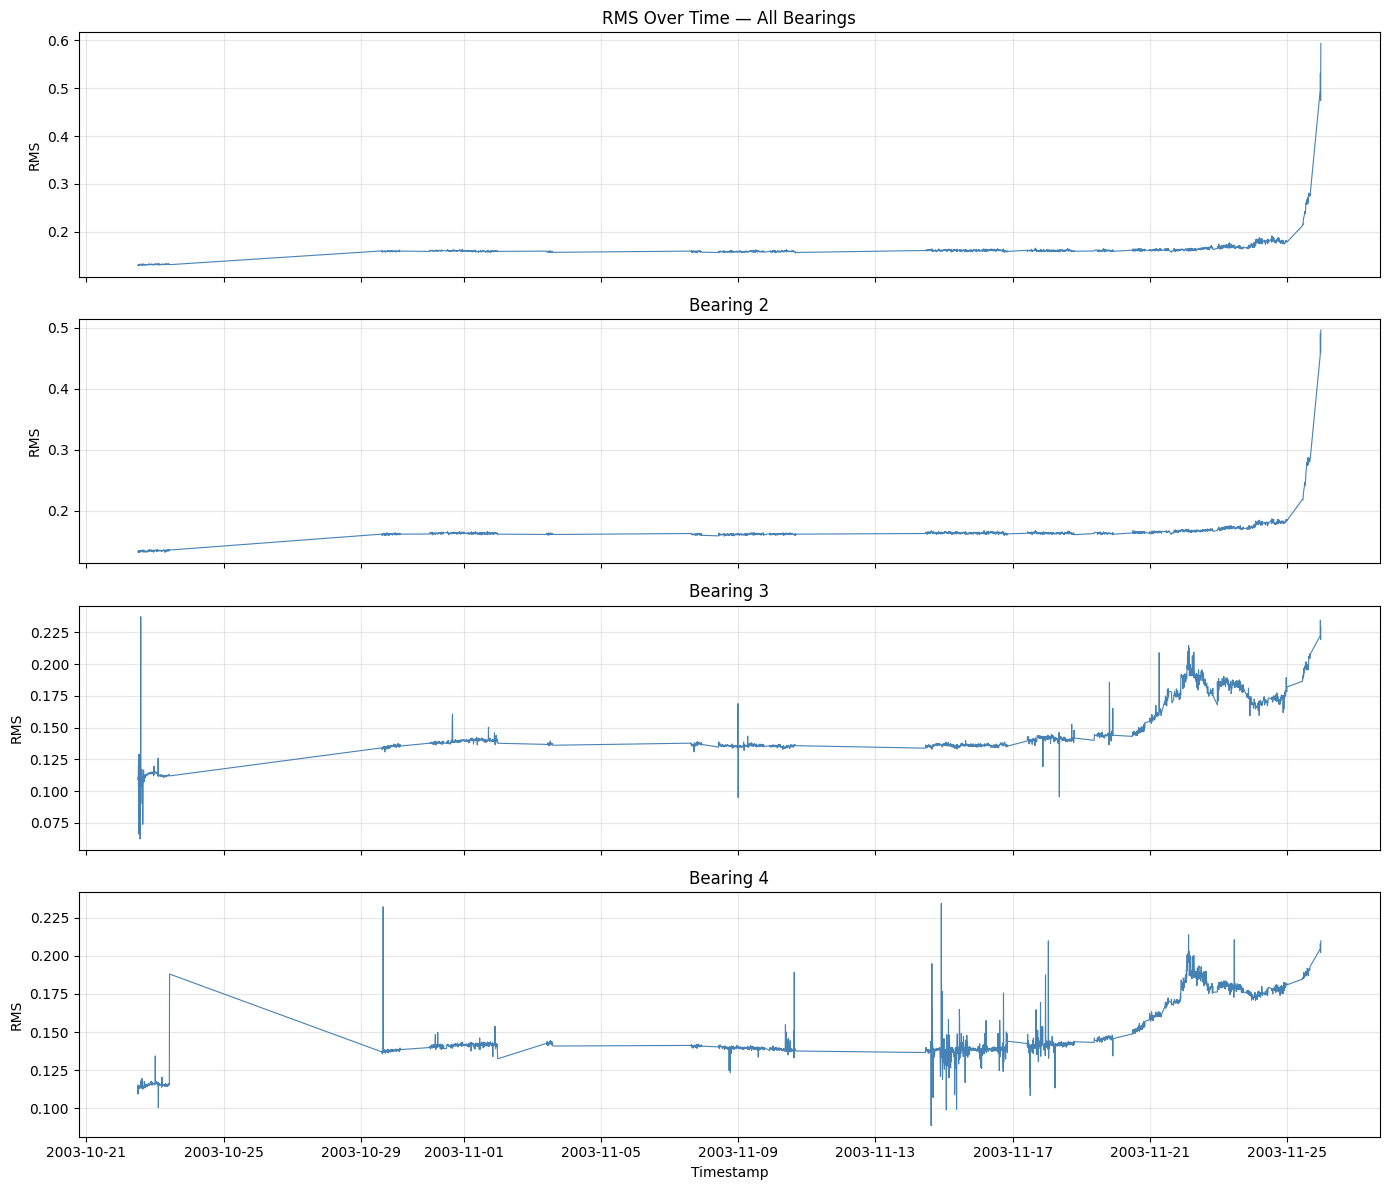

In [3]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

for i, b in enumerate(BEARINGS):
    axes[i].plot(stats_df.index, stats_df[f"{b}_rms"], linewidth=0.8, color="steelblue")
    axes[i].set_ylabel("RMS")
    axes[i].set_title(b.replace("_", " ").title())

axes[0].set_title("RMS Over Time — All Bearings")
axes[-1].set_xlabel("Timestamp")
plt.tight_layout()
plt.savefig("../outputs/figures/02_rms_over_time.png", dpi=150)
plt.show()

## Kurtosis Over Time
Kurtosis measures the "tailedness" of the signal distribution, it spikes sharply 
when impulsive events occur, such as a ball or race defect striking repeatedly. 
It is one of the most sensitive early indicators of bearing failure.

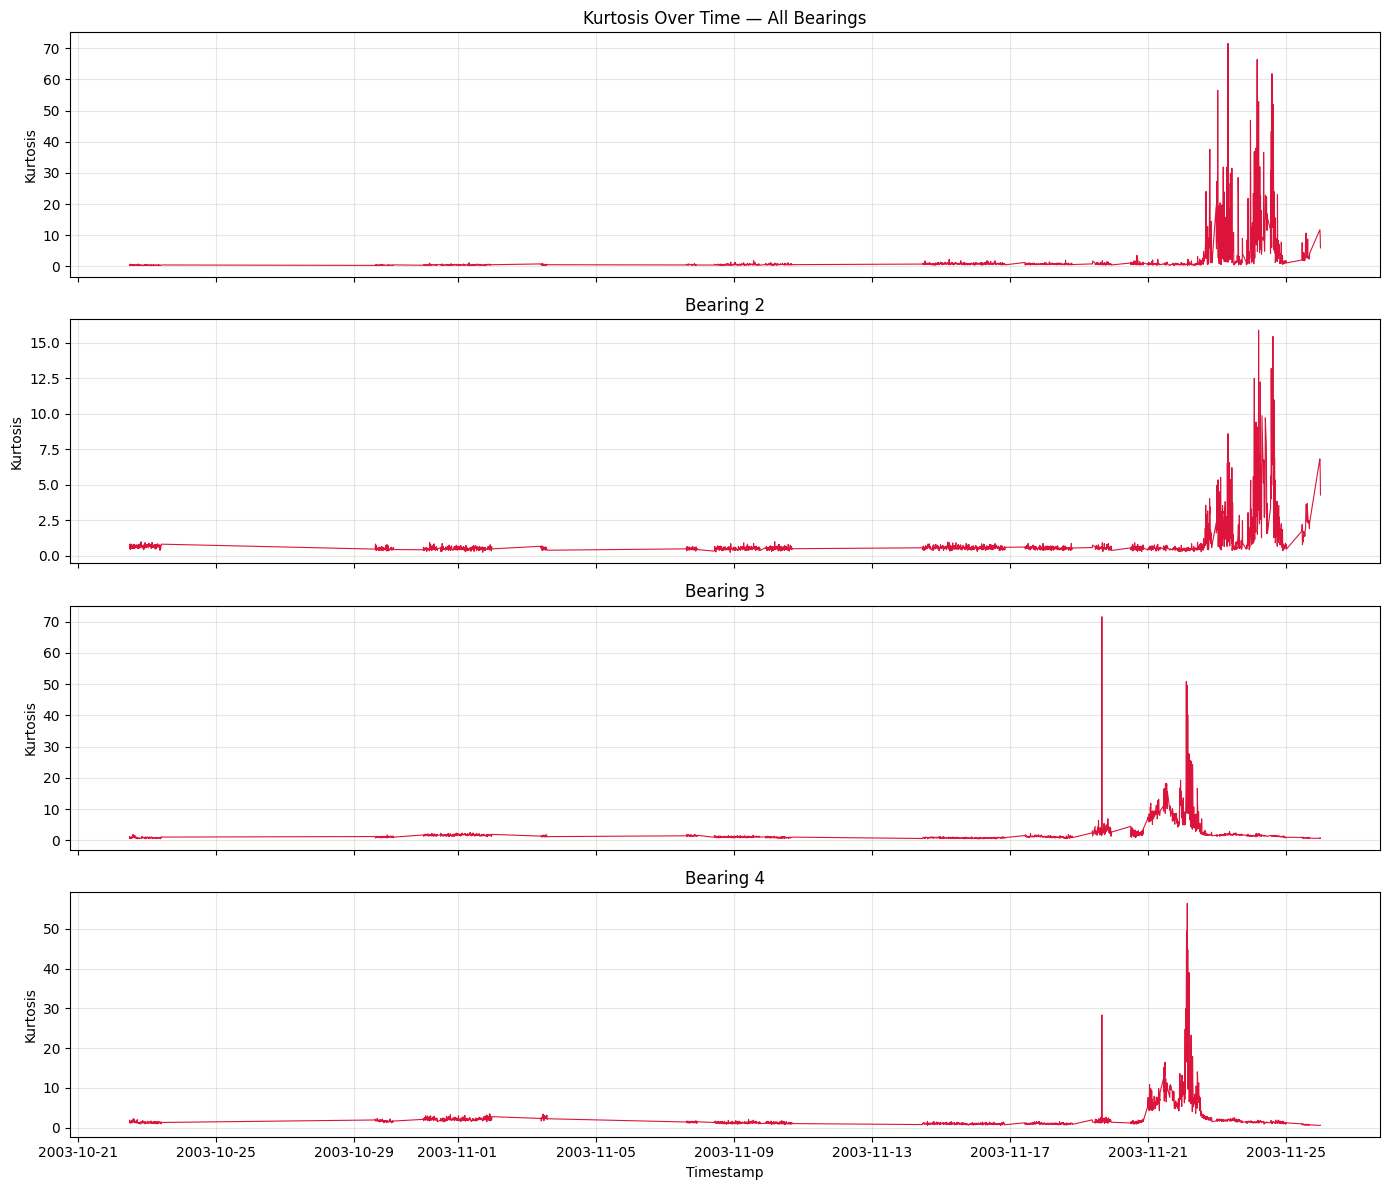

In [4]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

for i, b in enumerate(BEARINGS):
    axes[i].plot(stats_df.index, stats_df[f"{b}_kurtosis"], linewidth=0.8, color="crimson")
    axes[i].set_ylabel("Kurtosis")
    axes[i].set_title(b.replace("_", " ").title())

axes[0].set_title("Kurtosis Over Time — All Bearings")
axes[-1].set_xlabel("Timestamp")
plt.tight_layout()
plt.savefig("../outputs/figures/02_kurtosis_over_time.png", dpi=150)
plt.show()